# **Amazon Alexa Review - Sentiment Analysis**

Analyzing the Amazon Alexa dataset and building classification models to predict if the sentiment of a given input sentence is positive or negative.

## **Importing required libraries**


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Exploratory Data Analysis**

In [19]:
# Load the data

data = pd.read_csv("Data/amazon_alexa.tsv",delimiter='\t',quoting=3)
data.shape

(3150, 5)

In [20]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [21]:
#Column names

print(f"Feature names : {data.columns.values}")

Feature names : ['rating' 'date' 'variation' 'verified_reviews' 'feedback']


In [22]:
#Check for null values

data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [23]:
# Finding the record where "Verified_reviews" is null 

data[data['verified_reviews'].isna() == True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [24]:
# We will drop the null recored to clean the data 

data.dropna(inplace=True)

In [25]:
print(f"Dataset shape after dropping null values : {data.shape}")

Dataset shape after dropping null values : (3149, 5)


In [26]:
# Creating a new coloumn "length" that will contain the length of the string in "verified_reviews" column 

data['length'] = data['verified_reviews'].apply(len)
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


The 'length' column is new generated column - stores the length of 'verified_reviews' for that record. Let's check for some sample records

### **Datatypes of the features**

In [27]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

* Rating, Feedback, Length are integer values 
* Date, Variation, Verified_reviews are string values 

### **Analysing `rating` column**

This column refers to the rating of the variation given by the user 

In [28]:
len(data)

3149

In [29]:
# Distinct values of 'rating' and its count 

print(f"Rating value count: \n {data['rating'].value_counts()}")

Rating value count: 
 rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


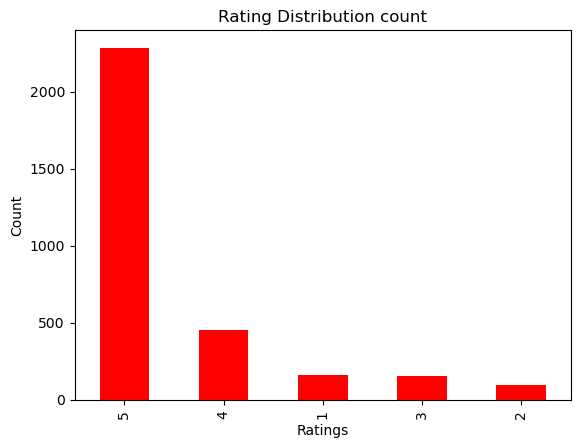

In [30]:
# Bar plot to visualize the total counts of each rating 

data['rating'].value_counts().plot.bar(color='red')
plt.title("Rating Distribution count")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

In [31]:
# Finding the percentage distribution of each rating - we will divide the number of records for each rating by total number of records

print(f"Rating value count - Percentage Distribution: \n{round(data['rating'].value_counts()/data.shape[0]*100,2)}")

Rating value count - Percentage Distribution: 
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


Plotting a Pie-Chart of the above values 

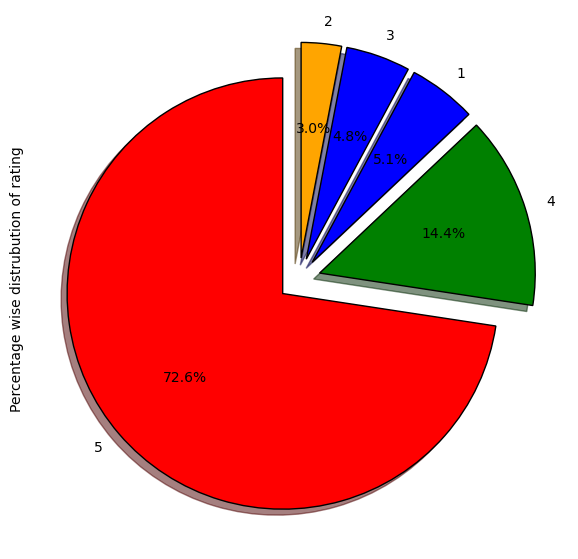

In [32]:
fig = plt.figure(figsize=(7,7))
colors = ('red','green','blue','blue','orange','yellow')
wp = {'linewidth':1,"edgecolor":"black"}
tags = data['rating'].value_counts()/data.shape[0]
explode = (0.1,0.1,0.1,0.1,0.1)
tags.plot(kind='pie',autopct="%1.1f%%", shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explode, label='Percentage wise distrubution of rating')

from io import BytesIO
graph = BytesIO()
fig.savefig(graph,format="png")

### **Analysing `feedback` column**

This column refers to the feedback of the verified review

In [33]:
# Distinct values of feedback and its count
print(f"Feedback value count: \n{data['feedback'].value_counts()}")

Feedback value count: 
feedback
1    2893
0     256
Name: count, dtype: int64


There are 2 distinct values of 'feedback' present - 0 and 1. Let's see what kind of review each value corresponds to.


In [34]:
# Extracting the 'verified_reviews' value for one record with feedback = 0

review_0 = data[data['feedback'] == 0 ].iloc[1]['verified_reviews']
print(review_0)

Sound is terrible if u want good music too get a bose


In [35]:
#Extracting the 'verified_reviews' value for one record with feedback = 1

review_1 = data[data['feedback'] == 1].iloc[1]['verified_reviews']
print(review_1)

Loved it!


From the above 2 examples we can see that feedback **0 is negative review** and **1 is positive review**

Let's plot the feedback value count in a bar graph

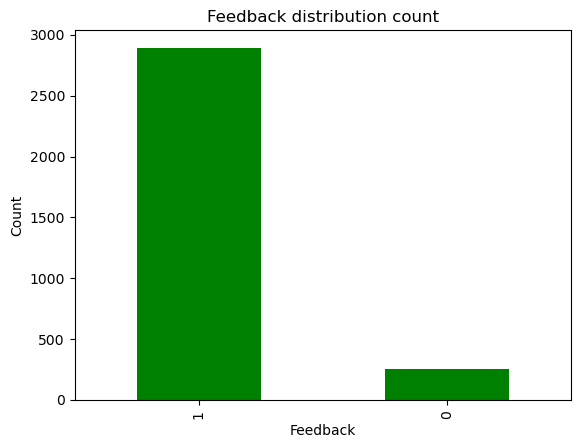

In [36]:
#Bar graph to visualize the total counts of each feedback

data['feedback'].value_counts().plot.bar(color = 'Green')
plt.title('Feedback distribution count')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

In [37]:
# Finding the percentage distribution of each feedback - we will divide the number of records for each feedback by total number of records

print(f"Feedback value count - percentage distribution: \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value count - percentage distribution: 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


Feedback distribution <br>
* 91.87% reviews are positive <br>
* 8.13% reviews are negative

<Axes: ylabel='Percentage wise distrubution of feedback'>

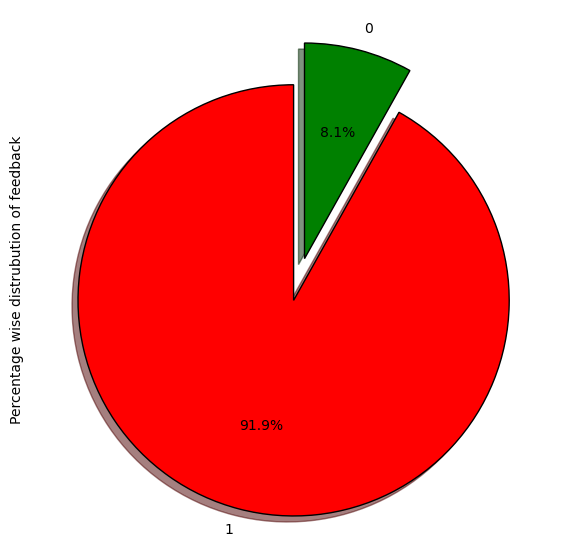

In [38]:
fig = plt.figure(figsize=(7,7))

colors = ('red', 'green')

wp = {'linewidth':1, "edgecolor":'black'}

tags = data['feedback'].value_counts()/data.shape[0]

explode=(0.1,0.1)

tags.plot(kind='pie', autopct="%1.1f%%", shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explode, label='Percentage wise distrubution of feedback')

### **Analysing the different `rating` values for different values of `feedback`**

In [39]:
# Feedback = 0 
data[data['feedback'] == 0]['rating'].value_counts()

rating
1    161
2     95
Name: count, dtype: int64

In [40]:
# Feedback = 1
data[data['feedback'] == 1]['rating'].value_counts()

rating
5    2286
4     455
3     152
Name: count, dtype: int64

If rating of a review is 1 or 2 then the feedback is 0 (negative) and if the rating is 3, 4 or 5 then the feedback is 1 (positive).

### **Analyzing `variation` column**

This column refers to the variation or type of Amazon Alexa product. Example - Black Dot, Charcoal Fabric etc.

In [41]:
#Distinct values of 'variation' and its count 

print(f"Variation value count: \n{data['variation'].value_counts()}")

Variation value count: 
variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64


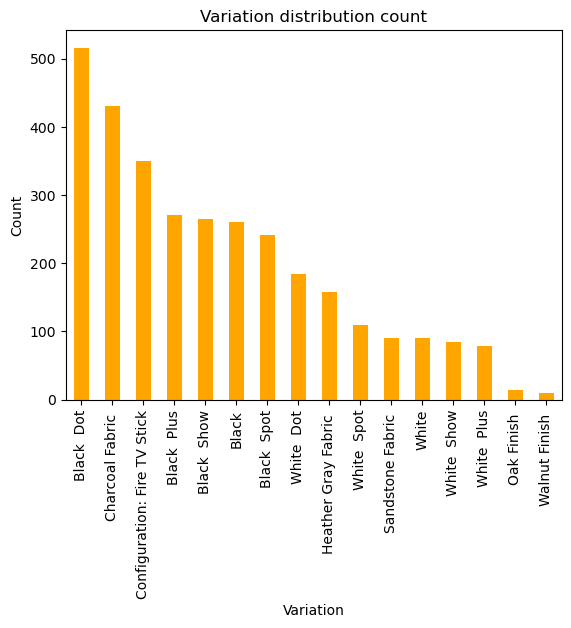

In [42]:
#Bar graph to visualize the total counts of each variation

data['variation'].value_counts().plot.bar(color = 'orange')
plt.title('Variation distribution count')
plt.xlabel('Variation')
plt.ylabel('Count')
plt.show()

In [43]:
#Finding the percentage distribution of each variation - we'll divide the number of records for each variation by total number of records

print(f"Variation value count - percentage distribution: \n{round(data['variation'].value_counts()/data.shape[0]*100,2)}")

Variation value count - percentage distribution: 
variation
Black  Dot                      16.39
Charcoal Fabric                 13.66
Configuration: Fire TV Stick    11.11
Black  Plus                      8.57
Black  Show                      8.42
Black                            8.29
Black  Spot                      7.65
White  Dot                       5.84
Heather Gray Fabric              4.99
White  Spot                      3.46
Sandstone Fabric                 2.86
White                            2.86
White  Show                      2.70
White  Plus                      2.48
Oak Finish                       0.44
Walnut Finish                    0.29
Name: count, dtype: float64


### **Mean `rating` according to `variation`**

In [44]:
data.groupby('variation')['rating'].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.166667
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
Name: rating, dtype: float64

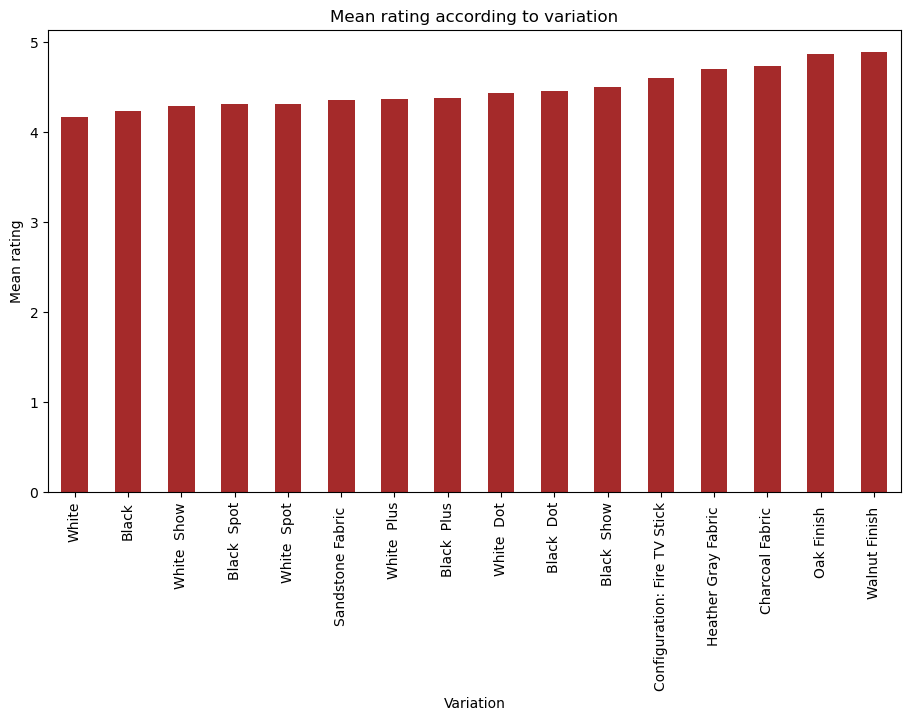

In [45]:
data.groupby('variation')['rating'].mean().sort_values().plot.bar(color = 'brown', figsize=(11, 6))
plt.title("Mean rating according to variation")
plt.xlabel('Variation')
plt.ylabel('Mean rating')
plt.show()

### Analyzing `verified_reviews` column

This column contains the textual review given by the user for a variation for the product.

In [46]:
data['length'].describe()

count    3149.000000
mean      132.714513
std       182.541531
min         1.000000
25%        30.000000
50%        74.000000
75%       166.000000
max      2853.000000
Name: length, dtype: float64

Length Analysis of review for full dataset

[Text(0.5, 1.0, 'Distribution of length of review ')]

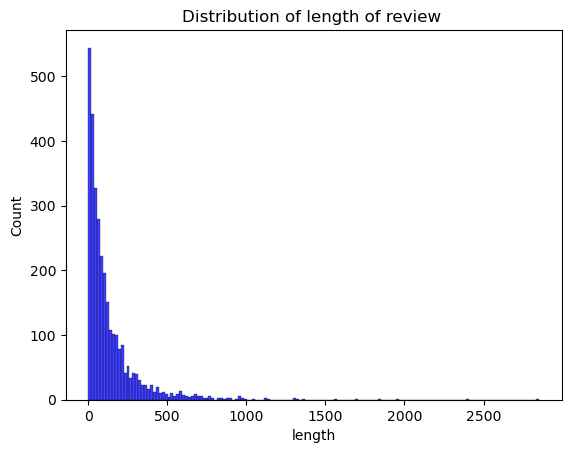

In [47]:
sns.histplot(data['length'],color='blue').set(title='Distribution of length of review ')

Length analysis of reviews when feedback is 0 (Negative)

[Text(0.5, 1.0, 'Distribution of length of review if feedback = 0')]

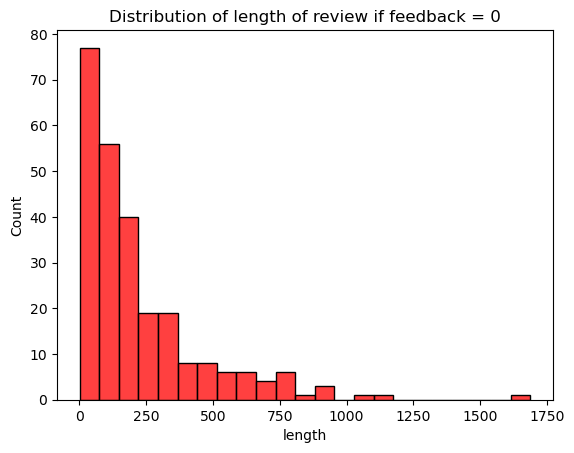

In [48]:
sns.histplot(data[data['feedback']==0]['length'],color='red').set(title='Distribution of length of review if feedback = 0')

Length Analysis when feedback is 1 (Positive)

[Text(0.5, 1.0, 'Distribution of length of review if feedback = 1')]

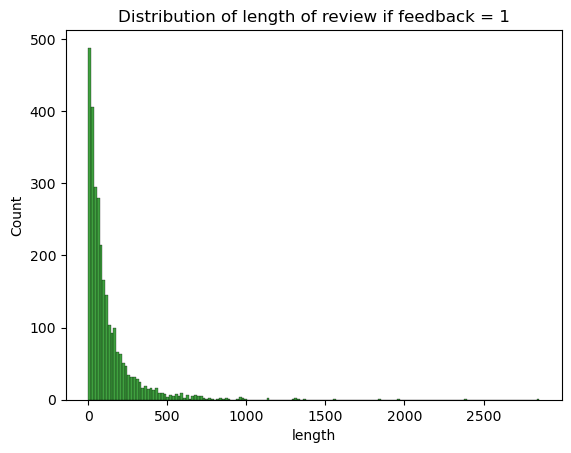

In [49]:
sns.histplot(data[data['feedback']==1]['length'],color='green').set(title='Distribution of length of review if feedback = 1')

Lengthwise mean rating 

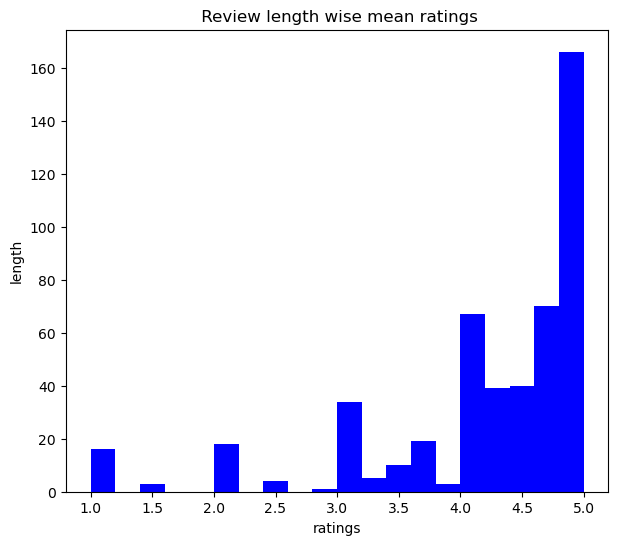

In [50]:
data.groupby('length')['rating'].mean().plot.hist(color = 'blue', figsize=(7, 6), bins = 20)
plt.title(" Review length wise mean ratings")
plt.xlabel('ratings')
plt.ylabel('length')
plt.show()

### **Wordcloud for all reviews from `verified_reviews`**

Vectorizing the Amazon Reviews

In [51]:
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(data.verified_reviews)

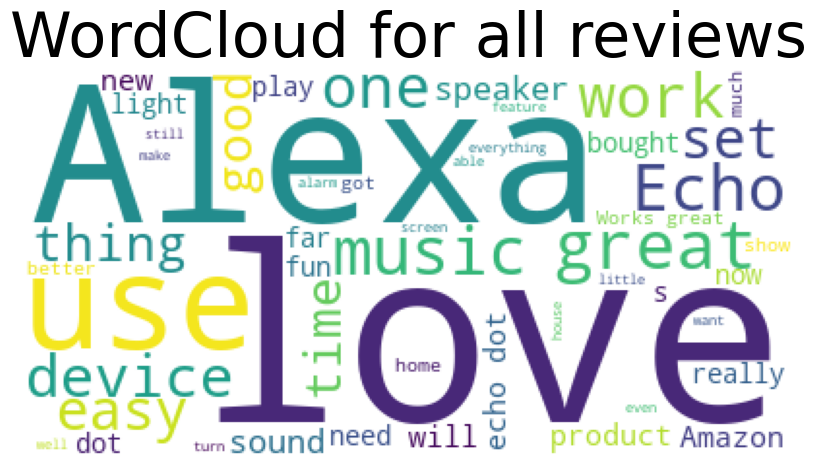

In [52]:
# Combine all reviews
reviews = " ".join([review for review in data['verified_reviews']])

# Initialzie wordcloud object 
wc = WordCloud(background_color='white',max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(reviews))
plt.title('WordCloud for all reviews',fontsize = 45)
plt.axis('off')
plt.show()

In [53]:
# Combine all reviews for each feedback category and splitting them into indivisual words

neg_reviews = " ".join([review for review in data[data['feedback']== 0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in data[data['feedback']== 1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()

# Finding words from reviews which are present in that feedback category only 
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)


### **Wordcloud for negative reviews from `verified_reviews`**

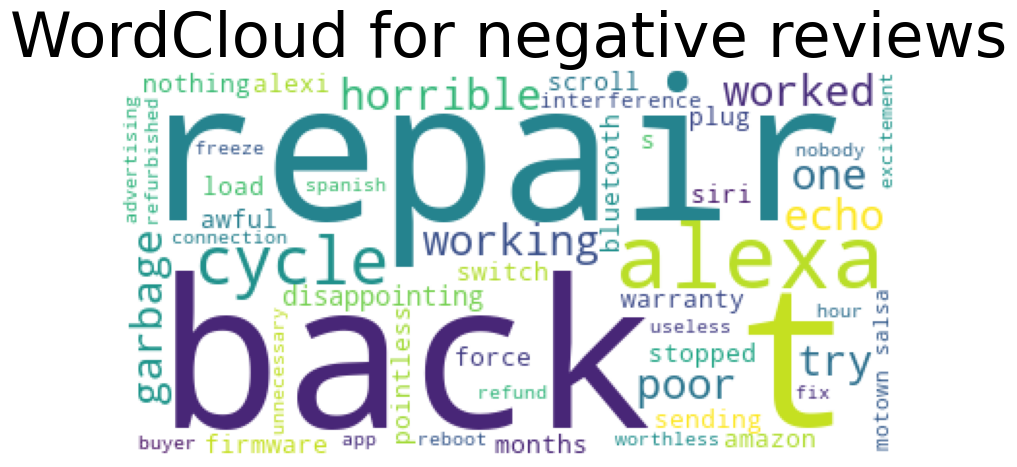

In [54]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title('WordCloud for negative reviews', fontsize = 45)
plt.axis('off')
plt.show()

### **Wordcloud for positive reviews from `verified_reviews`**

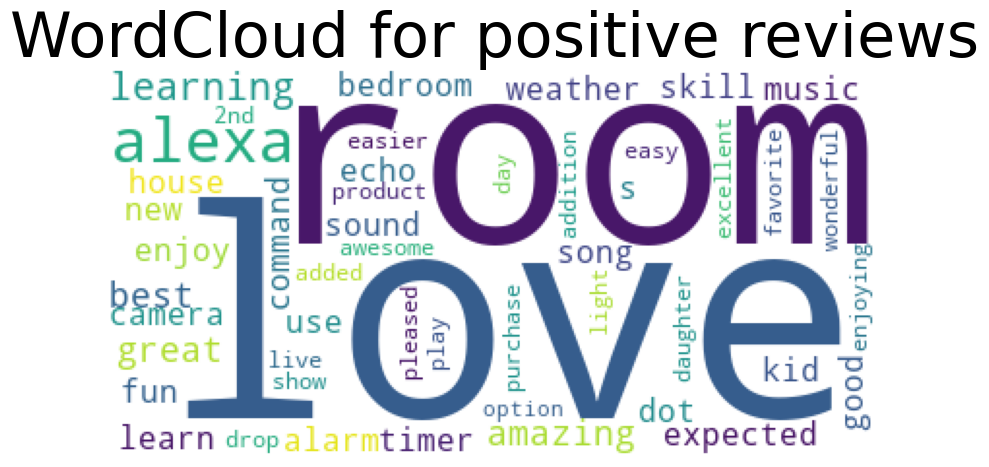

In [55]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title('WordCloud for positive reviews', fontsize = 45)
plt.axis('off')
plt.show()

## **Preprocessing and Modelling**
To build the corpus from the 'verified_reviews' we perform the following - <br>
1. Replace any non alphabet characters with a space
2. Covert to lower case and split into words
3. Iterate over the individual words and if it is not a stopword then add the stemmed form of the word to the corpus

In [56]:
corpus = []
stemmer = PorterStemmer()
for i in range(0, data.shape[0]):
  review = re.sub('[^a-zA-Z]', ' ', data.iloc[i]['verified_reviews'])
  review = review.lower().split()
  review = [stemmer.stem(word) for word in review if not word in STOPWORDS]
  review = ' '.join(review)
  corpus.append(review)

Using Count Vectorizer to create bag of words 

In [57]:
cv = CountVectorizer(max_features=2500)

# Storing independent and dependent variables in x and y    
X = cv.fit_transform(corpus).toarray()
Y = data['feedback'].values

In [58]:
# Saving the count vectorizer 
pickle.dump(cv, open('CountVectorizer.pkl','wb'))

Checking the shape of X and Y

In [59]:
print(f"X Shape: {X.shape}")
print(f"Y Shape: {Y.shape}")

X Shape: (3149, 2500)
Y Shape: (3149,)


Splitting data into Train and Test split

In [60]:
X_Train,X_Test,Y_Train,Y_Test = train_test_split(X,Y,test_size=0.3,random_state=15)

print(f"X_Train Shape: {X_Train.shape}")
print(f"X_Test Shape: {X_Test.shape}")
print(f"Y_Train Shape: {Y_Train.shape}")
print(f"Y_Test Shape: {Y_Test.shape}")

X_Train Shape: (2204, 2500)
X_Test Shape: (945, 2500)
Y_Train Shape: (2204,)
Y_Test Shape: (945,)


In [61]:
print(f"X_Train max value: {X_Train.max()}")
print(f"X_Test max value: {X_Test.max()}")

X_Train max value: 12
X_Test max value: 10


We will scale X_Test,X_Train so that all values are between 0,1

In [62]:
Scaler = MinMaxScaler()

X_Train_scl = Scaler.fit_transform(X_Train)
X_Test_scl = Scaler.transform(X_Test)

In [63]:
# Saving the scalar model 
pickle.dump(Scaler,open('Scaler.pkl','wb'))

### **RandomForest**

In [64]:
# Fitting scaled X_Train and Y_Train on RandomForestClassifier

Model = RandomForestClassifier()
Model.fit(X_Train_scl,Y_Train)

RandomForestClassifier()

In [65]:
# Accuracy of model on training and testing data 

print("Training Accuracy :", Model.score(X_Train_scl,Y_Train))
print("Testing Accuracy :", Model.score(X_Test_scl,Y_Test))

Training Accuracy : 0.9945553539019963
Testing Accuracy : 0.944973544973545


In [66]:
# Predicting on the test set

Y_Prediction = Model.predict(X_Test_scl)

In [67]:
# Confusion Matrix

cm = confusion_matrix(Y_Test,Y_Prediction)

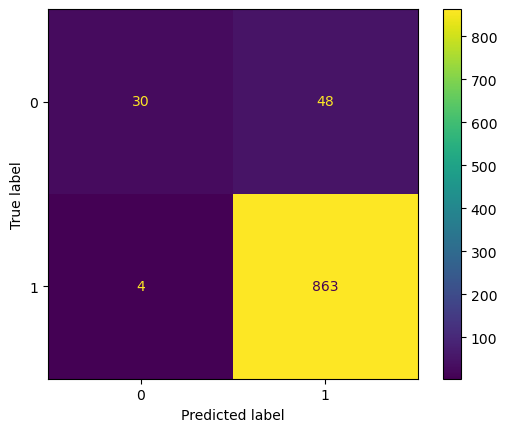

In [68]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=Model.classes_)
cm_display.plot()
plt.show()

K-Fold cross-validation

In [69]:
accuracies = cross_val_score(estimator=Model,X=X_Train_scl,y=Y_Train)

print("Accuracy :",accuracies.mean())
print("Standard Variance :", accuracies.std())

Accuracy : 0.9314904143475573
Standard Variance : 0.007349404674880153


In [70]:
#Applying grid search to get the optimal parameters on random forest

params = {
    'bootstrap':[True],
    'max_depth': [80,100],
    'min_samples_split':[8,12],
    'n_estimators':[100,300]
}

In [71]:
cv_object = StratifiedKFold(n_splits=2)

grid_search = GridSearchCV(estimator=Model,param_grid=params,cv=cv_object,verbose=0,return_train_score=True)

grid_search.fit(X_Train_scl,Y_Train.ravel())

GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True], 'max_depth': [80, 100],
                         'min_samples_split': [8, 12],
                         'n_estimators': [100, 300]},
             return_train_score=True)

In [72]:
#Getting the best parameters from the grid search


print("Best Parameter Combination : {}".format(grid_search.best_params_))

Best Parameter Combination : {'bootstrap': True, 'max_depth': 100, 'min_samples_split': 8, 'n_estimators': 100}


In [73]:
print("Cross validation mean accuracy on train set : {}".format(grid_search.cv_results_['mean_train_score'].mean()*100))
print("Cross validation mean accuracy on test set : {}".format(grid_search.cv_results_['mean_test_score'].mean()*100))
print("Accuracy score for test set :", accuracy_score(Y_Test, Y_Prediction))

Cross validation mean accuracy on train set : 96.75022686025409
Cross validation mean accuracy on test set : 92.19033575317604
Accuracy score for test set : 0.944973544973545


### **XGBoost**

In [74]:
Model_XGB = XGBClassifier()
Model_XGB.fit(X_Train_scl,Y_Train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [75]:
# Accuracy of model on training and testing data 

print("Training Accuracy :", Model_XGB.score(X_Train_scl,Y_Train))
print("Testing Accuracy :", Model_XGB.score(X_Test_scl,Y_Test))

Training Accuracy : 0.971415607985481
Testing Accuracy : 0.9417989417989417


In [76]:
Y_Prediction = Model_XGB.predict(X_Test)

In [77]:
# Confusion Matrix
cm = confusion_matrix(Y_Test,Y_Prediction)
print(cm)

[[ 31  47]
 [ 13 854]]


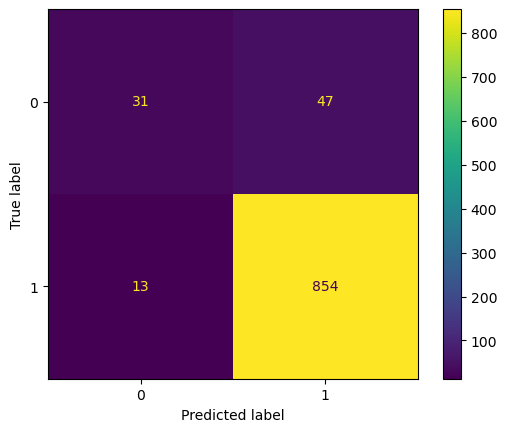

In [78]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=Model_XGB.classes_)
cm_display.plot()
plt.show()

In [79]:
# Saving the XGBoost Classifier
pickle.dump(Model_XGB,open('Model_XGB.pkl','wb'))

### **Decision Tree Classifier**

In [80]:
Model_DT = DecisionTreeClassifier()
Model_DT.fit(X_Train_scl,Y_Train)

DecisionTreeClassifier()

In [81]:
# Accuracy of model on training and testing data 

print("Training Accuracy :", Model_DT.score(X_Train_scl,Y_Train))
print("Testing Accuracy :", Model_DT.score(X_Test_scl,Y_Test))

Training Accuracy : 0.9945553539019963
Testing Accuracy : 0.9248677248677248


In [82]:
Y_Prediction = Model_DT.predict(X_Test)

In [83]:
# Confusion Matrix 

cm = confusion_matrix(Y_Test,Y_Prediction)
print(cm)

[[ 37  41]
 [ 52 815]]


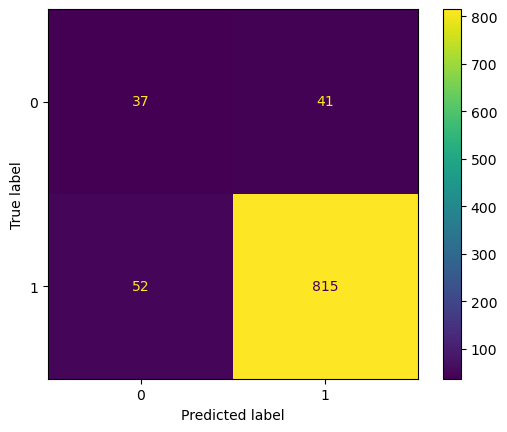

In [84]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=Model_DT.classes_)
cm_display.plot()
plt.show()